<h1 align="center"> Baseline Models </h1>

<br>
<i> Import necessary libraries: <i>

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier 
import matplotlib.pyplot as plt
import sklearn.metrics as mx
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

from src.optimise import capitalize_j, format_case_id

np.random.seed(2)

<i> Helper Functions: <i>

In [2]:
def spearman_df_function(features, target, threshold):
    feature_names = []
    feature_correlations = []
    
    column_names = features.columns.tolist()

    for column in column_names:
        corr, pval = spearmanr(features[column], target)
        if (corr >= threshold):
            feature_names.append(column)
            feature_correlations.append(corr)

    return feature_names, feature_correlations

def modelPerformance(confMat):
    TN = confMat[0, 0]
    TP = confMat[1, 1]
    FP = confMat[0, 1]
    FN = confMat[1, 0]
    prec = TP / (TP + FP)
    rec = TP / (TP + FN)
    spec = TN / (TN + FP)
    fpr = FP / (TN + FP)
    f1 = 2 * (prec * rec) / (prec + rec)
    acc = (TP + TN) / (TP + FP + TN + FN)
    return (acc, prec, rec, spec, fpr, f1)

def printPerformance(confMat):
    acc, prec, rec, spec, fpr, f1 = modelPerformance(confMat)
    print("Accuracy = " "%.4f" % acc)
    print("Precision = " "%.4f" % prec)
    print("Recall = " "%.4f" % rec)
    print("Specificity = " "%.4f" % spec)
    print("False positive rate = " "%.4f" % fpr)
    print("F1-score = " "%.4f" % f1)
    np.set_printoptions(precision=2)
    print("Confusion matrix (%):")
    print(confMat/np.sum(confMat)*100)

def proximityMatrix(mdl, X, normalize=True):      
    endNode = mdl.apply(X)
    nTrees = endNode.shape[1]
    n = X.shape[0]
    proxMat = np.zeros((n,n))
    for k in range(0, nTrees):
        a = endNode[:,k]
        proxMat += 1*np.equal.outer(a, a)
    if normalize:
        proxMat = proxMat / nTrees
    return proxMat

### Matching Samples for Analysis

In [3]:
# Step 1: Load RNA-Seq data
df_rna = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/rna_counts/RNA_counts_141024.csv", header=None, low_memory=False)
df_rna_transposed = df_rna.transpose()
new_header = df_rna_transposed.iloc[1]
df_rna_transposed = df_rna_transposed[2:]
df_rna_transposed.columns = new_header
df_rna_transposed.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces

# Step 3: Filter RNA data for 'ENSG' columns
rna_cols = df_rna_transposed.filter(like='ENSG')

# Step 4: Load and merge image data
df_images = pd.read_excel("/home/kryan24/MRes_Ultrasound/data/metadata/RNA_Sample_Linking2.xlsx")
df_images.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces
df_images['Sample ID'] = df_images['Sample ID'].str.replace(' ', '_')
df_images["SURGICAL"] = df_images["SURGICAL"].str.strip() # Remove whitespaces from SURGICAL

df_merged = pd.merge(df_images, df_rna_transposed, left_on="Sample ID", right_on="Geneid")

df_merged_copy = df_merged

# Step 5: Correct data quality issues
df_merged["Extraction site"] = df_merged["Extraction site"].str.strip()
df_merged["Extraction site"] = df_merged["Extraction site"].str.lower()

# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)

# Filter columns
df_radiomics = df_radiomics.drop(df_radiomics.iloc[:, 3907:3950], axis=1)
df_radiomics["MAHCINE_CORECCTED"] = df_radiomics["MAHCINE_CORECCTED"].str.strip() # Remove whitespaces from MAHCINE_CORECCTED

# Step 7: Match radiomics data to metadata and filter DataFrame
df_radiomics_meta = df_merged[["Extraction site", "SURGICAL", "CASE ID", "CASE ID2"]]

# Step 8: Merge DataFrames
df_merged2 = pd.merge(df_radiomics_meta, df_radiomics, left_on="CASE ID", right_on="ID")

# Step 9: Correct data quality issues
df_merged2 = df_merged2.drop(["ID"], axis=1)

# Step 10: Keep the same samples for RNA as radiomics data
case_id_list = df_merged2["CASE ID"].tolist()
mask = df_merged["CASE ID"].isin(case_id_list)
df_merged = df_merged[mask]

In [4]:
# Check length of both paired sample dataframes
print("Number of rows in paired radiomics samples:", df_merged2.shape[0])
print("Number of rows in paired RNA samples:", df_merged.shape[0])

Number of rows in paired radiomics samples: 36
Number of rows in paired RNA samples: 36


### Pair Images and RNA data

In [5]:
# Filter radiomics data 
rad_cols = df_merged2.drop(["Extraction site", "SURGICAL", "CASE ID", "CASE ID2", "MAHCINE_CORECCTED"], axis=1)

# Step 1: Prepare image filenames and filter data
image_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/images_matched"
image_filenames_rna = []
image_filenames_rad = []
rna_data_filtered = []
rad_data_filtered = []
surgical_rna = []
surgical_rad = []
sample_count_rna = 0 
sample_count_rad = 0 

rna_paired_id_list = []
rad_paired_id_list = [] 

In [6]:
for index, row in df_merged.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected) or (case_id2 and case_id2 in file_name_corrected):
                    image_filenames_rna.append(file_name)
                    rna_data_filtered.append(
                        row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rna.append(row["SURGICAL"])
                    sample_count_rna += 1
                    break  # Only use the first matching image for each row

print(f"Number of Samples: ", sample_count_rna)

Number of Samples:  29


In [7]:
for index, row in df_merged2.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
            if file_name.endswith('.nii.gz') and 'seg' not in file_name:
                file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

                # Check if either case_id or case_id2 is a substring of the filename
                # Only check if the ID is non-empty
                if (case_id and case_id in file_name_corrected) or (case_id2 and case_id2 in file_name_corrected):
                    image_filenames_rad.append(file_name)
                    rad_data_filtered.append(
                        row[rad_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                    surgical_rad.append(row["SURGICAL"])
                    sample_count_rad += 1
                    break  # Only use the first matching image for each row

print(f"Number of Samples: ", sample_count_rad)

Number of Samples:  29


In [8]:
flag = (surgical_rna == surgical_rad)
print(f"Matching Diagnoses: ", flag)

flag2 = (image_filenames_rna == image_filenames_rna)
print(f"Matching Images: ", flag2)

Matching Diagnoses:  True
Matching Images:  True


In [9]:
# Step 11: Obtain unpaired data for validation
unpaired_rad_filtered = df_radiomics[~df_radiomics["ID"].isin(rad_paired_id_list)]
df_unpaired_radiomics_meta = df_images[["Extraction site", "SURGICAL", "CASE ID", "CASE ID2"]].drop_duplicates(subset=["CASE ID"])
df_unpaired_rad = pd.merge(df_unpaired_radiomics_meta, unpaired_rad_filtered, left_on="CASE ID", right_on="ID")
df_unpaired_rad = df_unpaired_rad.drop(["ID"], axis=1)

df_unpaired_rna = df_merged_copy[~df_merged_copy["CASE ID"].isin(rna_paired_id_list)]

In [10]:
# Check length of both unpaired sample dataframes
print("Number of rows in unpaired radiomics samples:", df_unpaired_rad.shape[0])
print("Number of rows in unpaired RNA samples:", df_unpaired_rna.shape[0])

Number of rows in unpaired radiomics samples: 47
Number of rows in unpaired RNA samples: 39


### Train-test Split

In [11]:
# Convert to DataFrame
rad_data_filtered = pd.DataFrame(rad_data_filtered)
# Convert to DataFrame
rna_data_filtered = pd.DataFrame(rna_data_filtered)

In [12]:
# Step 1: Split into train and test sets
rad_train, rad_test, rna_train, rna_test, surg_train, surg_test, img_train, img_test = train_test_split(rad_data_filtered, rna_data_filtered, surgical_rad, image_filenames_rad, test_size=0.2, random_state=2)

In [13]:
# Convert back to DataFrame
rad_train = pd.DataFrame(rad_train, columns=rad_data_filtered.columns)
rad_test = pd.DataFrame(rad_test, columns=rad_data_filtered.columns)
# Convert back to DataFrame
rna_train = pd.DataFrame(rna_train, columns=rna_data_filtered.columns)
rna_test = pd.DataFrame(rna_test, columns=rna_data_filtered.columns)

In [14]:
print(f"Number of RNA samples: ", rna_train.shape[0])
print(f"Number of radiomics samples: ", rad_train.shape[0])
print(f"Number of image filenames: ", len(img_train))
print(f"Number of diagnoses: ", len(surg_train))
print(f"Image filenames: ", img_train)
print(f"Diagnoses: ", surg_train)

Number of RNA samples:  23
Number of radiomics samples:  23
Number of image filenames:  23
Number of diagnoses:  23
Image filenames:  ['24903_0011.nii.gz', '14984_0039.nii.gz', '14056_3.nii.gz', '25962_0006.nii.gz', '26604_0007.nii.gz', '26428_0020.nii.gz', '187867.nii.gz', '14654_3.nii.gz', '16439_0004.nii.gz', '14024_2.nii.gz', '25970_2.nii.gz', '25607_0005.nii.gz', '14023_3.nii.gz', '16106_0022.nii.gz', '26425_-3.nii.gz', '26417_1.nii.gz', '25827_0006.nii.gz', '18638_0037.nii.gz', 'J630_0008.nii.gz', '26379_5.nii.gz', '18853_0020.nii.gz', '24354_0019.nii.gz', '16134_0049.nii.gz']
Diagnoses:  ['M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S']


In [15]:
print(f"Number of RNA samples: ", rna_test.shape[0])
print(f"Number of radiomics samples: ", rad_test.shape[0])
print(f"Number of image filenames: ", len(img_test))
print(f"Number of diagnoses: ", len(surg_test))
print(f"Image filenames: ", img_test)
print(f"Diagnoses: ", surg_test)

Number of RNA samples:  6
Number of radiomics samples:  6
Number of image filenames:  6
Number of diagnoses:  6
Image filenames:  ['13291_0010.nii.gz', '12930_3.nii.gz', '18852_0009.nii.gz', '16208_1.nii.gz', '25961_2.nii.gz', '26424_0007.nii.gz']
Diagnoses:  ['M-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S']


# Radiomics Model

### Radiomics Tabular Data

In [16]:
# Scale radiomics sample counts
scaler = StandardScaler()
rad_train_df = pd.DataFrame(scaler.fit_transform(rad_train), columns=rad_data_filtered.columns)
rad_train_df.insert(0, "SURGICAL", surg_train)

rad_test_df = pd.DataFrame(scaler.fit_transform(rad_test), columns=rad_data_filtered.columns)
rad_test_df.insert(0, "SURGICAL", surg_test)

In [17]:
# Filter features selected using Spearman Rho
rad_all = rad_train_df.drop(["SURGICAL"], axis=1)
rad_class_cat = pd.Categorical(rad_train_df["SURGICAL"].astype("category")).codes
rad_feature_names, rad_feature_correlations = spearman_df_function(rad_all, rad_class_cat, 0.4)

/tmp/ipykernel_89026/3746739423.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [18]:
spearman_df = pd.DataFrame(
    {
        "Features": rad_feature_names,
        "Correlations": rad_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,GLSZM_ZoneHiGl_4gl,0.467099
1,GLCM_Varian_8gl,0.428174
2,GLCM_sumVar_8gl,0.408712
3,GLCM_ClTend_8gl,0.408712
4,GLCM_Varian_16gl,0.408712
...,...,...
76,GLCM_InfCo2_HHL_8gl,0.428174
77,GLSZM_SzVarianc_HHH_8gl,0.447637
78,GLRLM_SRLGLE_HHH_8gl,0.408712
79,FD_min_HHH_8gl,0.515883


In [19]:
# Store spearman features
spearman_rad = spearman_df["Features"].to_list()

In [20]:
# Seperating out the features
X_train_rad = rad_train_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
X_train_rad = X_train_rad.loc[:, X_train_rad.columns.isin(spearman_rad)]
# Seperating out the target
y_train_rad = rad_train_df[["SURGICAL"]]

### Fit Random Forest Model

In [21]:
# Set the random state for reproducibility
fit_rf_rad = RandomForestClassifier(n_estimators=1000, 
                                    class_weight="balanced", 
                                    random_state=2)

In [22]:
# Hyperparameter optimisation
param_dist = { "bootstrap": [True, False],
    "criterion": ["gini", "entropy"], 
    "max_features": ["sqrt", "log2", 0.5, 0.7, None]}

cv_rf_rad = GridSearchCV(fit_rf_rad, cv=3, param_grid=param_dist, verbose=3)

In [23]:
cv_rf_rad.fit(X_train_rad, y_train_rad.values.ravel())
print('Best Parameters using grid search: \n', 
      cv_rf_rad.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV 1/3] END bootstrap=True, criterion=gini, max_features=sqrt;, score=0.875 total time=   0.9s
[CV 2/3] END bootstrap=True, criterion=gini, max_features=sqrt;, score=1.000 total time=   0.9s
[CV 3/3] END bootstrap=True, criterion=gini, max_features=sqrt;, score=0.857 total time=   1.0s
[CV 1/3] END bootstrap=True, criterion=gini, max_features=log2;, score=0.875 total time=   0.9s
[CV 2/3] END bootstrap=True, criterion=gini, max_features=log2;, score=0.875 total time=   0.9s
[CV 3/3] END bootstrap=True, criterion=gini, max_features=log2;, score=0.857 total time=   0.9s
[CV 1/3] END bootstrap=True, criterion=gini, max_features=0.5;, score=0.875 total time=   0.9s
[CV 2/3] END bootstrap=True, criterion=gini, max_features=0.5;, score=1.000 total time=   0.9s
[CV 3/3] END bootstrap=True, criterion=gini, max_features=0.5;, score=0.857 total time=   0.9s
[CV 1/3] END bootstrap=True, criterion=gini, max_features=0.7;, score=0.875 to

In [24]:
# Set best parameters given by grid search
fit_rf_rad.set_params(criterion = "gini",
                     max_features = "sqrt")

RandomForestClassifier(class_weight='balanced', n_estimators=1000,
                       random_state=2)

### Out of Bag Error Rate

In [25]:
fit_rf_rad.set_params(n_estimators=100,
                        warm_start=True, 
                        oob_score=True)

min_estimators = 10
max_estimators = 1000
min_oob_error = 1.0
min_index = 0

error_rate = {}

for i in range(min_estimators, max_estimators + 1):
    fit_rf_rad.set_params(n_estimators=i)
    fit_rf_rad.fit(X_train_rad, y_train_rad.values.ravel())

    oob_error = 1 - fit_rf_rad.oob_score_
    error_rate[i] = oob_error

    if min_oob_error > oob_error:
        min_oob_error = oob_error
        min_index = i

print("min_oob_error = ", min_oob_error)
print("min_index = ", min_index)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency

min_oob_error =  0.13043478260869568
min_index =  10


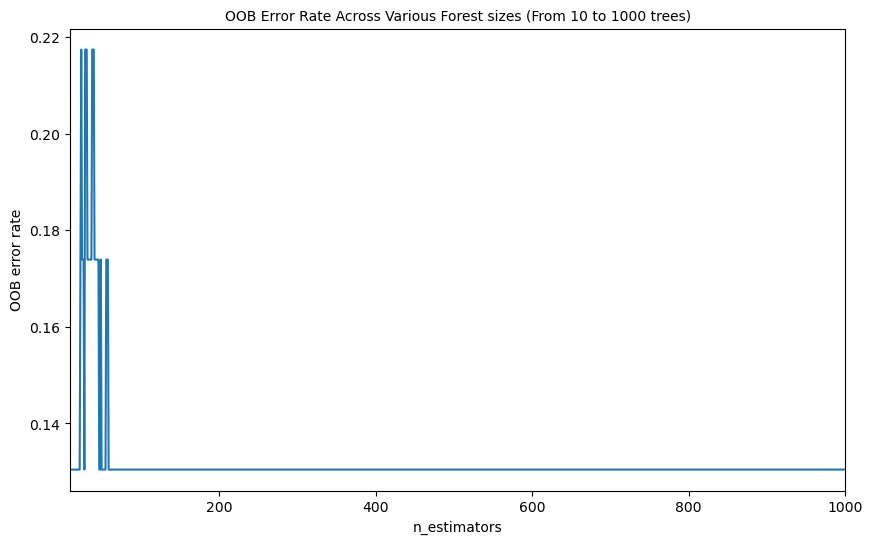

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(min_estimators, max_estimators)
plt.plot(num_estimators, oob_error)
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 1000 trees)", fontsize=10)
plt.show()

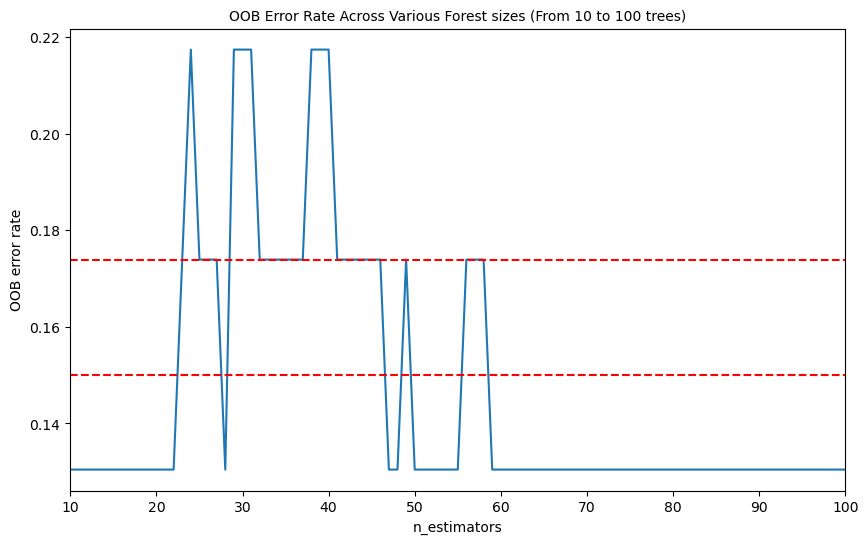

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(min_estimators, 100)
plt.plot(num_estimators, oob_error)
plt.axhline(0.17391304347826086, color="red", linestyle="--")
plt.axhline(0.15, color="red", linestyle="--")
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 100 trees)", fontsize=10)
plt.show()

### Build Random Forest Model Using Best Parameters

In [28]:
# Create the classifier
fit_rf_rad.set_params(n_estimators=55, 
                      bootstrap=True, 
                      warm_start=False,
                      criterion= "gini",
                      max_features= "sqrt",
                      oob_score=True,
                      class_weight= "balanced", 
                      random_state=2)

RandomForestClassifier(class_weight='balanced', n_estimators=55, oob_score=True,
                       random_state=2)

In [29]:
# Fit the model to the training set
fit_rf_rad.fit(X_train_rad, y_train_rad)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(class_weight='balanced', n_estimators=55, oob_score=True,
                       random_state=2)

### Visualise Feature Importance

In [30]:
# Feature scores
feature_scores = pd.Series(fit_rf_rad.feature_importances_, index=X_train_rad.columns).sort_values(ascending=True)
feature_scores = feature_scores[feature_scores > 0]

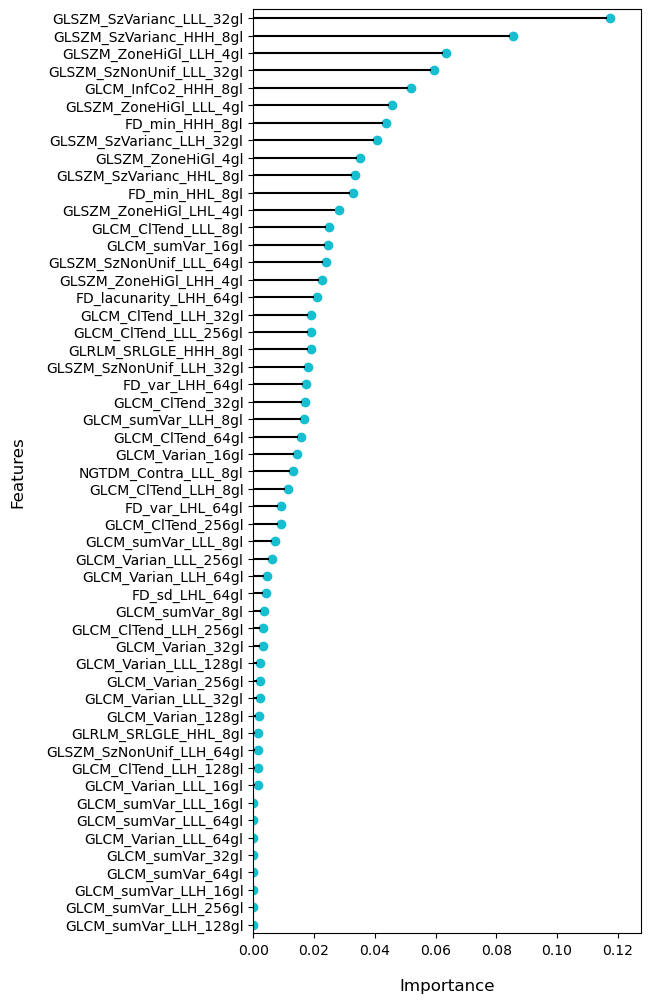

In [31]:
fig, ax = plt.subplots(figsize=(5, 12))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

ax.scatter(x=feature_scores, y=feature_scores.index, color="#17BECF")
miny, nexty, *_, maxy = ax.get_yticks()
eps = (nexty - miny) / 2 
ax.set_ylim(miny-eps, maxy+eps)
ax.set_xlim(0, max(feature_scores+0.01))
for x, y in zip(feature_scores, feature_scores.index):
    plt.hlines(y = y, xmin = 0, xmax = x-0.001, color="black") 
ax.tick_params(axis="both", which="major", labelsize=10)
ax.set_ylabel("Features", fontsize=12, labelpad=15)
ax.set_xlabel("Importance", fontsize=12, labelpad=15)

plt.show()


### Evaluate Model

#### Train

In [32]:
# Train 
y_train_rad_pred = cross_val_predict(fit_rf_rad, X_train_rad, y_train_rad, cv=3)
cmat = mx.confusion_matrix(y_train_rad, y_train_rad_pred)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [33]:
printPerformance(cmat)

Accuracy = 0.8696
Precision = 0.9048
Recall = 0.9500
Specificity = 0.3333
False positive rate = 0.6667
F1-score = 0.9268
Confusion matrix (%):
[[ 4.35  8.7 ]
 [ 4.35 82.61]]


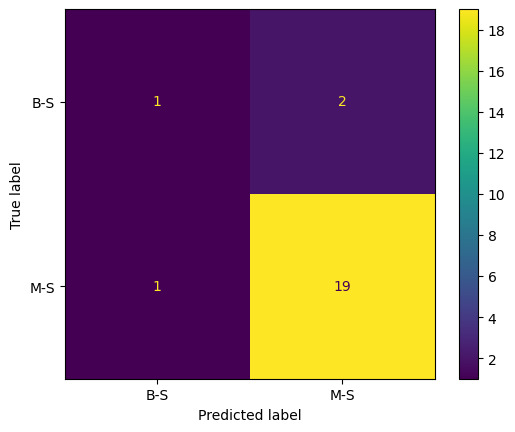

In [34]:
cm = confusion_matrix(y_train_rad, y_train_rad_pred, labels=fit_rf_rad.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rad.classes_)
disp.plot()

#### Test

In [35]:
# Test

# Seperating out the features
X_test_rad = rad_test_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
X_test_rad = X_test_rad.loc[:, X_test_rad.columns.isin(spearman_rad)]
# Seperating out the target
y_test_rad = rad_test_df[["SURGICAL"]]

y_test_rad_pred = fit_rf_rad.predict(X_test_rad)
cmat = mx.confusion_matrix(y_test_rad, y_test_rad_pred)

In [36]:
printPerformance(cmat)

Accuracy = 0.5000
Precision = 0.5000
Recall = 0.6667
Specificity = 0.3333
False positive rate = 0.6667
F1-score = 0.5714
Confusion matrix (%):
[[16.67 33.33]
 [16.67 33.33]]


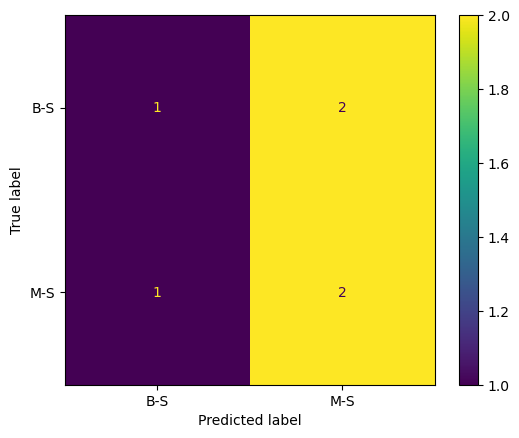

In [37]:
cm = confusion_matrix(y_test_rad, y_test_rad_pred, labels=fit_rf_rad.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rad.classes_)
disp.plot()

#### Validation (Unpaired Data)

In [38]:
rad_col_list = list(rad_train.columns.values)
rad_val = df_unpaired_rad.loc[:, df_unpaired_rad.columns.isin(rad_col_list)]
surg_val = df_unpaired_rad["SURGICAL"].to_list()

# Scale radiomics sample counts
scaler = StandardScaler()
rad_val_df = pd.DataFrame(scaler.fit_transform(rad_val), columns=rad_data_filtered.columns)
rad_val_df.insert(0, "SURGICAL", surg_val)


In [39]:
# Validation

# Seperating out the features
X_val_rad = rad_val_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
X_val_rad = X_val_rad.loc[:, X_val_rad.columns.isin(spearman_rad)]
# Seperating out the target
y_val_rad = rad_val_df[["SURGICAL"]]

y_val_rad_pred = fit_rf_rad.predict(X_val_rad)
cmat = mx.confusion_matrix(y_val_rad, y_val_rad_pred)

In [40]:
printPerformance(cmat)

Accuracy = 0.8298
Precision = 0.8444
Recall = 0.9744
Specificity = 0.1250
False positive rate = 0.8750
F1-score = 0.9048
Confusion matrix (%):
[[ 2.13 14.89]
 [ 2.13 80.85]]


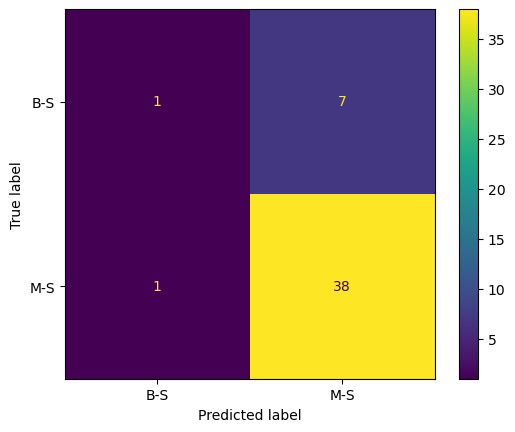

In [41]:
cm = confusion_matrix(y_val_rad, y_val_rad_pred, labels=fit_rf_rad.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rad.classes_)
disp.plot()

### Plot the ROC Curve

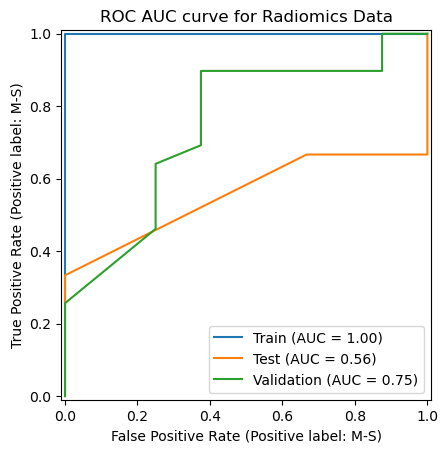

In [42]:
# Train data
disp = RocCurveDisplay.from_estimator(fit_rf_rad, X_train_rad, y_train_rad, pos_label='M-S', name="Train")

# Test data
disp = RocCurveDisplay.from_estimator(fit_rf_rad, X_test_rad, y_test_rad, pos_label='M-S', ax = disp.ax_, name="Test")

# Validation data
disp = RocCurveDisplay.from_estimator(fit_rf_rad, X_val_rad, y_val_rad, pos_label='M-S', ax = disp.ax_, name="Validation")

disp.ax_.set_title("ROC AUC curve for Radiomics Data");

# RNA Model

### RNA Tabular Data

In [43]:
# Scale RNA sample counts
scaler = StandardScaler()
rna_train_df = pd.DataFrame(scaler.fit_transform(rna_train), columns=rna_data_filtered.columns)
rna_train_df.insert(0, "SURGICAL", surg_train)

rna_test_df = pd.DataFrame(scaler.fit_transform(rna_test), columns=rna_data_filtered.columns)
rna_test_df.insert(0, "SURGICAL", surg_test)

In [44]:
# Filter features selected using Spearman Rho
rna_all = rna_train_df.drop(["SURGICAL"], axis=1)
rna_class_cat = pd.Categorical(rna_train_df["SURGICAL"].astype("category")).codes
rna_feature_names, rna_feature_correlations = spearman_df_function(rna_all, rna_class_cat, 0.5)

/tmp/ipykernel_89026/3746739423.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(features[column], target)


In [45]:
spearman_df = pd.DataFrame(
    {
        "Features": rna_feature_names,
        "Correlations": rna_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,ENSG00000189280,0.558978
1,ENSG00000163873,0.536678
2,ENSG00000143185,0.500767
3,ENSG00000162782,0.506525
4,ENSG00000197472,0.528498
...,...,...
240,ENSG00000161091,0.506024
241,ENSG00000225335,0.545354
242,ENSG00000242114,0.525487
243,ENSG00000128218,0.557859


In [46]:
# Store spearman features
spearman_rna = spearman_df["Features"].to_list()

In [47]:
# Seperating out the features
X_train_rna = rna_train_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
X_train_rna = X_train_rna.loc[:, X_train_rna.columns.isin(spearman_rna)]
# Seperating out the target
y_train_rna = rna_train_df[["SURGICAL"]]

### Fit Random Forest Model

In [48]:
# Set the random state for reproducibility
fit_rf_rna = RandomForestClassifier(n_estimators=1000, 
                                    class_weight="balanced", 
                                    random_state=2)

In [49]:
# Hyperparameter optimisation
param_dist = { "bootstrap": [True, False],
    "criterion": ["gini", "entropy"], 
    "max_features": ["sqrt", "log2", 0.5, 0.7, None]}

cv_rf_rna = GridSearchCV(fit_rf_rna, cv=3, param_grid=param_dist, verbose=3)

In [50]:
cv_rf_rna.fit(X_train_rna, y_train_rna.values.ravel())
print('Best Parameters using grid search: \n', 
      cv_rf_rna.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV 1/3] END bootstrap=True, criterion=gini, max_features=sqrt;, score=1.000 total time=   0.9s
[CV 2/3] END bootstrap=True, criterion=gini, max_features=sqrt;, score=1.000 total time=   0.9s
[CV 3/3] END bootstrap=True, criterion=gini, max_features=sqrt;, score=0.857 total time=   0.9s
[CV 1/3] END bootstrap=True, criterion=gini, max_features=log2;, score=1.000 total time=   0.9s
[CV 2/3] END bootstrap=True, criterion=gini, max_features=log2;, score=1.000 total time=   0.9s
[CV 3/3] END bootstrap=True, criterion=gini, max_features=log2;, score=0.857 total time=   0.9s
[CV 1/3] END bootstrap=True, criterion=gini, max_features=0.5;, score=1.000 total time=   1.0s
[CV 2/3] END bootstrap=True, criterion=gini, max_features=0.5;, score=1.000 total time=   1.0s
[CV 3/3] END bootstrap=True, criterion=gini, max_features=0.5;, score=0.857 total time=   1.0s
[CV 1/3] END bootstrap=True, criterion=gini, max_features=0.7;, score=1.000 to

In [51]:
# Set best parameters given by grid search
fit_rf_rna.set_params(criterion = "gini",
                     max_features = "sqrt")

RandomForestClassifier(class_weight='balanced', n_estimators=1000,
                       random_state=2)

### Out of Bag Error Rate

In [52]:
fit_rf_rna.set_params(n_estimators=100,
                        warm_start=True, 
                        oob_score=True)

min_estimators = 10
max_estimators = 1000
min_oob_error = 1.0
min_index = 0

error_rate = {}

for i in range(min_estimators, max_estimators + 1):
    fit_rf_rna.set_params(n_estimators=i)
    fit_rf_rna.fit(X_train_rna, y_train_rna.values.ravel())

    oob_error = 1 - fit_rf_rna.oob_score_
    error_rate[i] = oob_error

    if min_oob_error > oob_error:
        min_oob_error = oob_error
        min_index = i

print("min_oob_error = ", min_oob_error)
print("min_index = ", min_index)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency

min_oob_error =  0.08695652173913049
min_index =  22


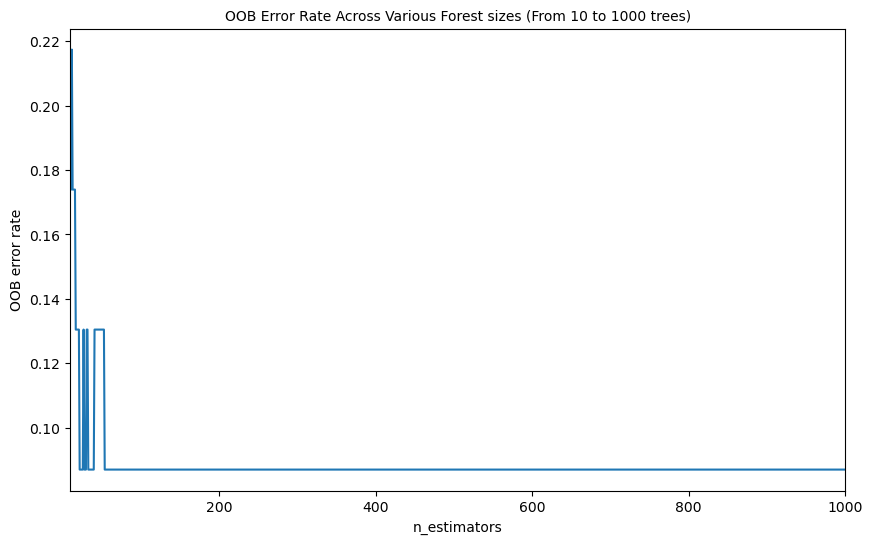

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(min_estimators, max_estimators)
plt.plot(num_estimators, oob_error)
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 1000 trees)", fontsize=10)
plt.show()

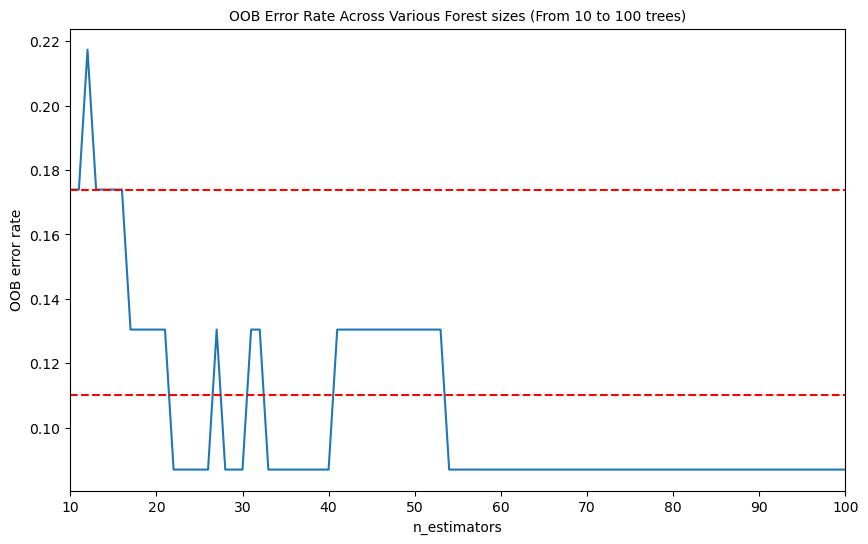

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

num_estimators = list(error_rate.keys())
oob_error = list(error_rate.values())

plt.xlim(min_estimators, 100)
plt.plot(num_estimators, oob_error)
plt.axhline(0.17391304347826086, color="red", linestyle="--")
plt.axhline(0.11, color="red", linestyle="--")
plt.xlabel("n_estimators", fontsize=10)
plt.ylabel("OOB error rate", fontsize=10)
plt.title("OOB Error Rate Across Various Forest sizes (From 10 to 100 trees)", fontsize=10)
plt.show()

### Build Random Forest Model Using Best Parameters

In [55]:
# Create the classifier
fit_rf_rna.set_params(n_estimators=40, 
                      bootstrap=True, 
                      warm_start=False,
                      criterion= "gini",
                      max_features= "sqrt",
                      oob_score=True,
                      class_weight= "balanced", 
                      random_state=2)

RandomForestClassifier(class_weight='balanced', n_estimators=40, oob_score=True,
                       random_state=2)

In [56]:
# Fit the model to the training set
fit_rf_rna.fit(X_train_rna, y_train_rna)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(class_weight='balanced', n_estimators=40, oob_score=True,
                       random_state=2)

### Visualise Feature Importance

In [57]:
# Feature scores
feature_scores = pd.Series(fit_rf_rna.feature_importances_, index=X_train_rna.columns).sort_values(ascending=True)
feature_scores = feature_scores[feature_scores > 0]

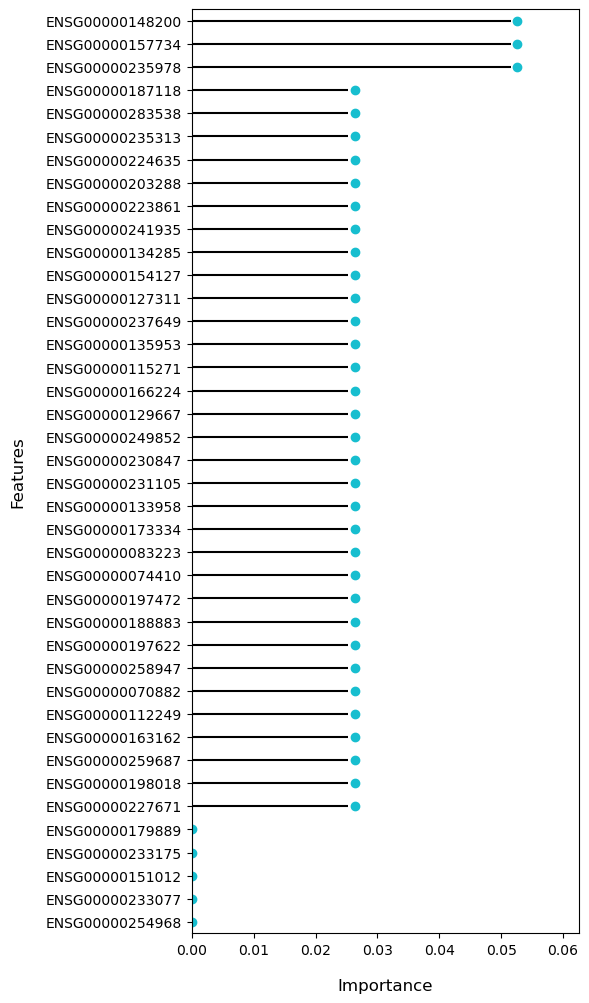

In [58]:
fig, ax = plt.subplots(figsize=(5, 12))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

ax.scatter(x=feature_scores, y=feature_scores.index, color="#17BECF")
miny, nexty, *_, maxy = ax.get_yticks()
eps = (nexty - miny) / 2 
ax.set_ylim(miny-eps, maxy+eps)
ax.set_xlim(0, max(feature_scores+0.01))
for x, y in zip(feature_scores, feature_scores.index):
    plt.hlines(y = y, xmin = 0, xmax = x-0.001, color="black") 
ax.tick_params(axis="both", which="major", labelsize=10)
ax.set_ylabel("Features", fontsize=12, labelpad=15)
ax.set_xlabel("Importance", fontsize=12, labelpad=15)

plt.show()

### Evaluate Model

#### Train

In [59]:
# Train 
y_train_rna_pred = cross_val_predict(fit_rf_rna, X_train_rna, y_train_rna, cv=3)
cmat = mx.confusion_matrix(y_train_rna, y_train_rna_pred)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [60]:
printPerformance(cmat)

Accuracy = 0.9565
Precision = 0.9524
Recall = 1.0000
Specificity = 0.6667
False positive rate = 0.3333
F1-score = 0.9756
Confusion matrix (%):
[[ 8.7   4.35]
 [ 0.   86.96]]


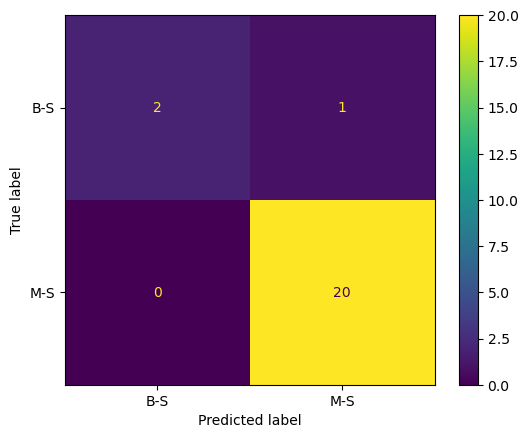

In [61]:
cm = confusion_matrix(y_train_rna, y_train_rna_pred, labels=fit_rf_rna.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rna.classes_)
disp.plot()

#### Test

In [62]:
# Test

# Seperating out the features
X_test_rna = rna_test_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
X_test_rna = X_test_rna.loc[:, X_test_rna.columns.isin(spearman_rna)]
# Seperating out the target
y_test_rna = rna_test_df[["SURGICAL"]]

y_test_rna_pred = fit_rf_rna.predict(X_test_rna)
cmat = mx.confusion_matrix(y_test_rna, y_test_rna_pred)

In [63]:
printPerformance(cmat)

Accuracy = 0.5000
Precision = 0.5000
Recall = 1.0000
Specificity = 0.0000
False positive rate = 1.0000
F1-score = 0.6667
Confusion matrix (%):
[[ 0. 50.]
 [ 0. 50.]]


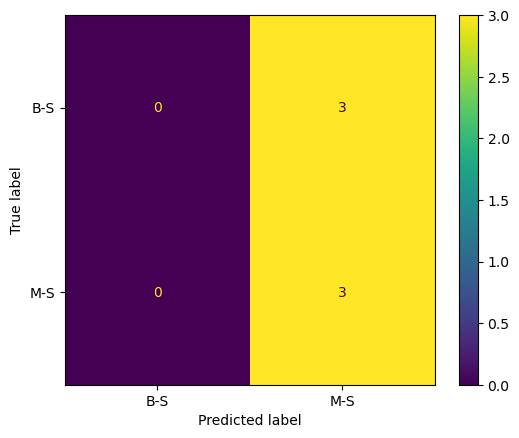

In [64]:
cm = confusion_matrix(y_test_rna, y_test_rna_pred, labels=fit_rf_rna.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rna.classes_)
disp.plot()

#### Validation (Unpaired Data)

In [65]:
rna_col_list = list(rna_train.columns.values)
rna_val = df_unpaired_rna.loc[:, df_unpaired_rna.columns.isin(rna_col_list)]
surg_val = df_unpaired_rna["SURGICAL"].to_list()

# Scale rnaiomics sample counts
scaler = StandardScaler()
rna_val_df = pd.DataFrame(scaler.fit_transform(rna_val), columns=rna_data_filtered.columns)
rna_val_df.insert(0, "SURGICAL", surg_val)

In [66]:
# Validation

# Seperating out the features
X_val_rna = rna_val_df.drop(["SURGICAL"], axis=1)
# Only keep the top features
X_val_rna = X_val_rna.loc[:, X_val_rna.columns.isin(spearman_rna)]
# Seperating out the target
y_val_rna = rna_val_df[["SURGICAL"]]

y_val_rna_pred = fit_rf_rna.predict(X_val_rna)
cmat = mx.confusion_matrix(y_val_rna, y_val_rna_pred)

In [67]:
printPerformance(cmat)

Accuracy = 0.8974
Precision = 0.8919
Recall = 1.0000
Specificity = 0.3333
False positive rate = 0.6667
F1-score = 0.9429
Confusion matrix (%):
[[ 5.13 10.26]
 [ 0.   84.62]]


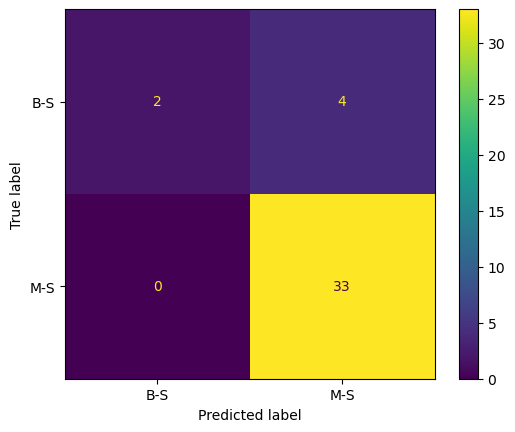

In [68]:
cm = confusion_matrix(y_val_rna, y_val_rna_pred, labels=fit_rf_rna.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_rf_rna.classes_)
disp.plot()

### Plot the ROC Curve

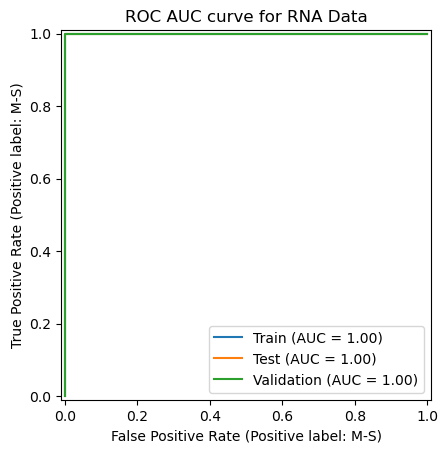

In [69]:
# Train data
disp = RocCurveDisplay.from_estimator(fit_rf_rna, X_train_rna, y_train_rna, pos_label='M-S', name="Train")

# Test data
disp = RocCurveDisplay.from_estimator(fit_rf_rna, X_test_rna, y_test_rna, pos_label='M-S', ax = disp.ax_, name="Test")

# Validation data
disp = RocCurveDisplay.from_estimator(fit_rf_rna, X_val_rna, y_val_rna, pos_label='M-S', ax = disp.ax_, name="Validation")

disp.ax_.set_title("ROC AUC curve for RNA Data");